# Inspect Raw Exposure & Vulnerability Source Files 

- Source: data/exposure_vulnerability_raw/

- plots the **native, pre-resampling** files cached in `data/exposure_vulnerability_raw/`

- Each map's metadata is also provided 

- Every map below is cropped to the project's domain
( **33-48 degrees E, 3-15 degrees N**) 

- All maps are shown at **native resolution**, not yet resampled onto the 0.25 degree grid. 


## Mapping every raw file to its config entry


| Raw file  | Feeds config entry | Consumed by |
|---|---|---|
| `worldpop_eth_ppp_2020.tif` | `exposure_indicators.yaml: population` | Exposure |
| `glw4_cattle.tif` | `exposure_indicators.yaml: livestock_cattle` | Exposure |
| `GHS_BUILT_S_...tif` | `exposure_indicators.yaml: built_up` | Exposure |
| `gis_osm_roads_free_1.shp` | `exposure_indicators.yaml: roads` | Exposure |
| `gis_osm_buildings_a_free_1.shp` | `exposure_indicators.yaml: buildings` | Exposure |
| `healthsites_eth.csv` | `exposure_indicators.yaml: healthsites` + `vulnerability_indicators.yaml: wet.adaptive_capacity.healthsites` | Exposure + V_wet |
| `ai_v31_yr.tif` (aridity) | `vulnerability_indicators.yaml: drought.sensitivity.aridity_index` | V_drought |
| `gmia_v5_aei_pct.asc` | `vulnerability_indicators.yaml: drought.adaptive_capacity.irrigation_gmia` + exposure's cropland irrigated/rainfed split | V_drought + Exposure |
| `gdessa_noaccess_ssa_2014_2020.nc` | `vulnerability_indicators.yaml: drought.adaptive_capacity` + `wet.adaptive_capacity` (`electrification_no_access_rate`) | V_drought + V_wet |
| `gis_osm_waterways_free_1.shp` + `gis_osm_water_a_free_1.shp` | `vulnerability_indicators.yaml: wet.sensitivity.river_distance` | V_wet |
| `meta_rwi_eth.csv` | `vulnerability_indicators.yaml: drought.sensitivity.poverty_rwi` + `wet.sensitivity.poverty_rwi` | V_drought + V_wet |

## Table of contents

- [Exposure raw sources](#exposure-raw-sources)
  - [Population count (raw)](#population-count-raw)
  - [Livestock -- cattle (raw)](#livestock-cattle-raw)
  - [Built-up surface (raw)](#built-up-surface-raw)
  - [Roads (raw)](#roads-raw)
  - [Buildings (raw, centroid density)](#buildings-raw-centroid-density)
  - [Health facilities (raw points)](#health-facilities-raw-points)
- [Vulnerability raw sources](#vulnerability-raw-sources)
  - [Aridity index (raw, scaled)](#aridity-index-raw-scaled)
  - [Irrigated area % (raw)](#irrigated-area-raw)
  - [Electrification -- no access (raw, 2020 slice)](#electrification-no-access-raw-2020-slice)
  - [Waterways (raw)](#waterways-raw)
  - [Water bodies (raw)](#water-bodies-raw)
  - [Relative Wealth Index (raw points)](#relative-wealth-index-raw-points)


## Import Python Packages

In [75]:
%matplotlib inline
import textwrap
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
import rasterio.mask
import rasterio.plot
import xarray as xr
from affine import Affine
from rasterio.enums import Resampling
from IPython.display import display
from rasterio.io import MemoryFile

plt.rcParams.update({"font.size": 14, "axes.titlesize": 18, "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10})
warnings.filterwarnings("ignore", message="Geometry is in a geographic CRS")


## Input Path

In [76]:
raw_dir = Path("data/exposure_vulnerability_raw")

## Set Boundaries Files

In [77]:
boundary_path = Path("boundaries/eth_shapefile/eth_admin0.shp")
boundary_gdf = gpd.read_file(boundary_path).to_crs("EPSG:4326")
boundary_geom = boundary_gdf.geometry.iloc[0]
DOMAIN_BOUNDS = (33.0, 3.0, 48.0, 15.0)

def plot_boundary_outline(ax):
    boundary_gdf.boundary.plot(ax=ax, color="black", linewidth=1.0)


## Define Metadata

In [78]:
def print_metadata(meta):
    print(f"{meta['title']}  ({meta['path']})")
    print(f"  Category:          {meta['category']}")
    print(f"  Source:            {meta['source']}")
    print(f"  Native resolution: {meta['native_resolution']}")
    print(f"  Native extent:     {meta['native_extent']}")
    print(f"  Native format:     {meta['native_format']}")
    print(f"  Units (native):    {meta['units']}")
    print(f"  License:           {meta['license']}")
    if meta.get("note"):
        print("  Note:")
        for line in textwrap.wrap(meta["note"], width=100):
            print(f"    {line}")

## Open/Load GeoTiff File 

In [79]:
def _open_domain_window(path, max_pixels=4_000_000):
    with rasterio.open(path) as src:
        window = rasterio.windows.from_bounds(*DOMAIN_BOUNDS, transform=src.transform)
        window = window.round_offsets().round_lengths()
        win_h, win_w = int(window.height), int(window.width)
        src_nodata = src.nodata
        read_fill = src_nodata if src_nodata is not None else 0
        decimated = win_h * win_w > max_pixels
        if decimated:
            factor = (win_h * win_w / max_pixels) ** 0.5
            out_h, out_w = max(1, int(win_h / factor)), max(1, int(win_w / factor))
            raw = src.read(
                1, window=window, out_shape=(out_h, out_w), resampling=Resampling.average,
                boundless=True, fill_value=read_fill,
            )
            win_transform = src.window_transform(window) * Affine.scale(win_w / out_w, win_h / out_h)
        else:
            raw = src.read(1, window=window, boundless=True, fill_value=read_fill)
            win_transform = src.window_transform(window)
    data = raw.astype(np.float64)
    if src_nodata is not None:
        data[raw == src_nodata] = np.nan

    profile = dict(
        driver="GTiff", height=data.shape[0], width=data.shape[1], count=1,
        dtype="float64", crs="EPSG:4326", transform=win_transform, nodata=np.nan,
    )
    memfile = MemoryFile()
    with memfile.open(**profile) as dst:
        dst.write(data, 1)
    return memfile, memfile.open(), decimated

## Exposure

### Population Count (raw)

In [80]:
meta = dict(
    title='Population count (raw)',
    category='Exposure -- population',
    source='WorldPop gridded population count, Ethiopia 2020 (hub.worldpop.org)',
    native_resolution='~100 m (0.000833 deg)',
    native_extent='Ethiopia only (pre-clipped by the WorldPop API, not a global mosaic)',
    native_format='GeoTIFF, single band, float32',
    units='people per ~100 m pixel (count)',
    license='CC-BY 4.0',
    note="Already Ethiopia-extent as downloaded -- the only raw file here that isn't a global/regional mosaic needing a windowed read.",
)

In [81]:
def plot_raster_raw(fname, meta, cmap="viridis", scale_factor=None):
    meta = dict(meta)
    meta["path"] = fname
    print_metadata(meta)

    memfile, src, decimated = _open_domain_window(raw_dir / fname)
    if decimated:
        print(
            f"  Display note: source window exceeds 4M pixels; block-averaged to "
            f"{src.height} x {src.width} for rendering (native resolution above "
            f"describes the source file, not this decimated preview)."
        )
    try:
        clipped, out_transform = rasterio.mask.mask(src, [boundary_geom.__geo_interface__], crop=True)
        data = clipped[0].astype(float)
        data = np.ma.masked_invalid(data)
        if src.nodata is not None:
            data = np.ma.masked_equal(data, src.nodata)

        valid = data.compressed()
        if scale_factor is not None and valid.size:
            scaled = valid * scale_factor
            print(
                f"  Clipped stats (raw): n={valid.size}, min={valid.min():.3g}, "
                f"mean={valid.mean():.3g}, max={valid.max():.3g}"
            )
            print(
                f"  Clipped stats (x{scale_factor} applied): min={scaled.min():.3g}, "
                f"mean={scaled.mean():.3g}, max={scaled.max():.3g}"
            )
        elif valid.size:
            print(f"  Clipped stats: n={valid.size}, min={valid.min():.3g}, mean={valid.mean():.3g}, max={valid.max():.3g}")
        else:
            print("  Clipped stats: no valid pixels within the boundary")

        fig, ax = plt.subplots(figsize=(8, 8))
        im = ax.imshow(
            data, cmap=cmap, extent=rasterio.plot.plotting_extent(data, out_transform),
        )
        cbar = fig.colorbar(im, ax=ax, pad=0.03, shrink=0.75, fraction=0.05)
        cbar.set_label(meta["units"], fontsize=10)
        plot_boundary_outline(ax)
        ax.set_title(meta["title"], fontsize=14)
        ax.axis("off")
        fig.tight_layout()
        display(fig)
        plt.close(fig)
    finally:
        src.close()
        memfile.close()

Population count (raw)  (worldpop_eth_ppp_2020.tif)
  Category:          Exposure -- population
  Source:            WorldPop gridded population count, Ethiopia 2020 (hub.worldpop.org)
  Native resolution: ~100 m (0.000833 deg)
  Native extent:     Ethiopia only (pre-clipped by the WorldPop API, not a global mosaic)
  Native format:     GeoTIFF, single band, float32
  Units (native):    people per ~100 m pixel (count)
  License:           CC-BY 4.0
  Note:
    Already Ethiopia-extent as downloaded -- the only raw file here that isn't a global/regional mosaic
    needing a windowed read.
  Display note: source window exceeds 4M pixels; block-averaged to 1788 x 2236 for rendering (native resolution above describes the source file, not this decimated preview).
  Clipped stats: n=2046321, min=0.00427, mean=0.784, max=466


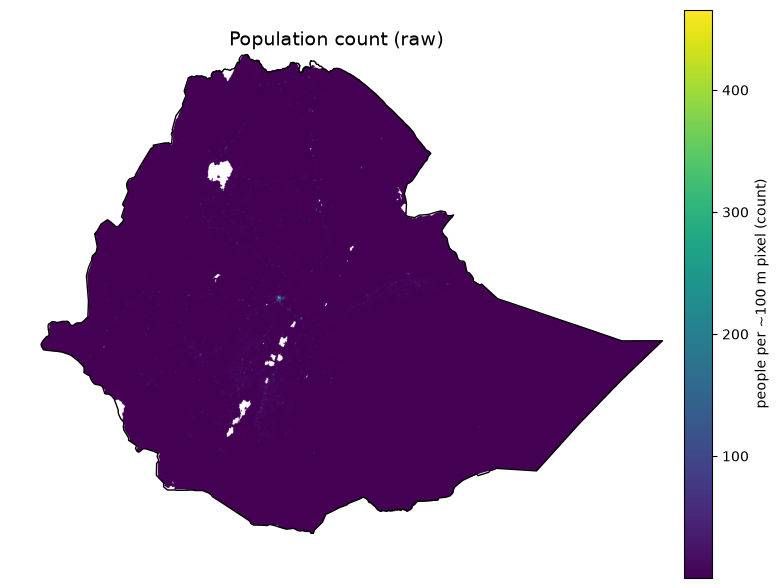

In [82]:
plot_raster_raw('worldpop_eth_ppp_2020.tif', meta, cmap="viridis")

### Livestock - Cattle (raw)

In [83]:
meta = dict(
    title='Livestock -- cattle (raw)',
    category='Exposure -- livestock',
    source='FAO Gridded Livestock of the World v4 (2020), cattle',
    native_resolution='5 arcmin (~10 km)',
    native_extent='Global (2160 x 4320)',
    native_format='GeoTIFF, single band, float32',
    units='head per km^2 (density, NOT yet converted to a per-pixel count)',
    license='CC-BY 4.0',
    note='Global raster windowed to the domain for display. The acquisition pipeline converts this density to a per-pixel head count (density x pixel area) before resampling -- the map below shows the raw density as downloaded, not the count.',
)

Livestock -- cattle (raw)  (glw4_cattle.tif)
  Category:          Exposure -- livestock
  Source:            FAO Gridded Livestock of the World v4 (2020), cattle
  Native resolution: 5 arcmin (~10 km)
  Native extent:     Global (2160 x 4320)
  Native format:     GeoTIFF, single band, float32
  Units (native):    head per km^2 (density, NOT yet converted to a per-pixel count)
  License:           CC-BY 4.0
  Note:
    Global raster windowed to the domain for display. The acquisition pipeline converts this density to
    a per-pixel head count (density x pixel area) before resampling -- the map below shows the raw
    density as downloaded, not the count.
  Clipped stats: n=13336, min=0, mean=62.2, max=864


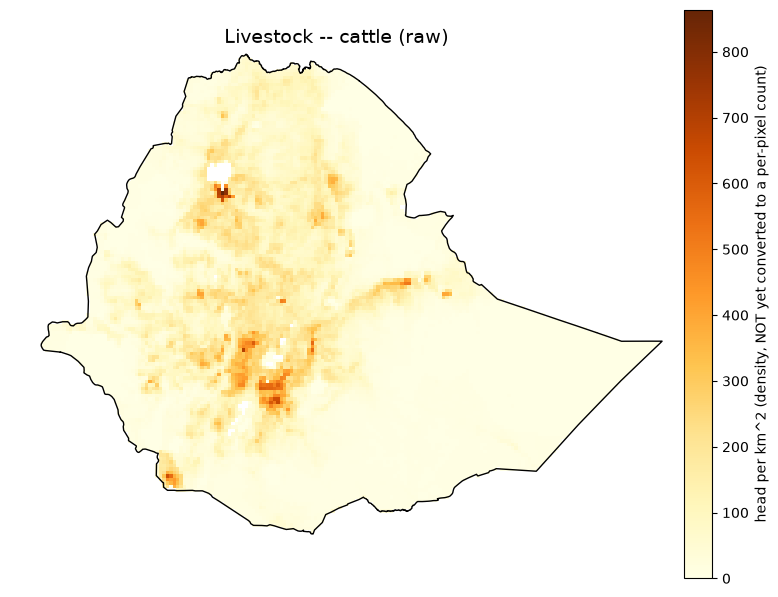

In [84]:
plot_raster_raw('glw4_cattle.tif', meta, cmap="YlOrBr")

### Built-up Surface (raw)

In [85]:
meta = dict(
    title='Built-up surface (raw)',
    category='Exposure -- infrastructure (built environment)',
    source='JRC GHSL GHS-BUILT-S R2023A, 2020 epoch',
    native_resolution='30 arcsec (~1 km)',
    native_extent='Global (21384 x 43201, ~924M pixels)',
    native_format='GeoTIFF, single band, uint32',
    units='m^2 built-up surface per pixel',
    license='CC-BY 4.0',
    note='Global mosaic -- reading the full array would raise ArrayMemoryError (~6.9 GiB); windowed to the domain here, same as the acquisition code.',
)

Built-up surface (raw)  (ghs_built_s_e2020_4326_30ss/GHS_BUILT_S_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif)
  Category:          Exposure -- infrastructure (built environment)
  Source:            JRC GHSL GHS-BUILT-S R2023A, 2020 epoch
  Native resolution: 30 arcsec (~1 km)
  Native extent:     Global (21384 x 43201, ~924M pixels)
  Native format:     GeoTIFF, single band, uint32
  Units (native):    m^2 built-up surface per pixel
  License:           CC-BY 4.0
  Note:
    Global mosaic -- reading the full array would raise ArrayMemoryError (~6.9 GiB); windowed to the
    domain here, same as the acquisition code.
  Clipped stats: n=1338025, min=0, mean=1.9e+03, max=8.48e+05


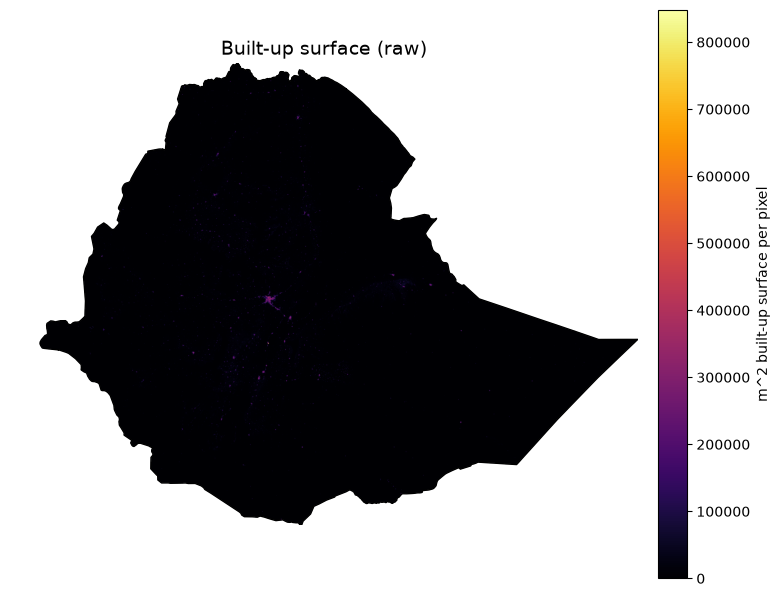

In [86]:
plot_raster_raw('ghs_built_s_e2020_4326_30ss/GHS_BUILT_S_E2020_GLOBE_R2023A_4326_30ss_V1_0.tif', meta, cmap="inferno")

### Roads (raw)

In [87]:
meta = dict(
    title='Roads (raw)',
    category='Exposure -- infrastructure',
    source='OpenStreetMap road network, via Geofabrik Ethiopia extract',
    native_resolution='vector (no fixed grid resolution)',
    native_extent='Ethiopia (Geofabrik country extract)',
    native_format='ESRI Shapefile (lines), 444,579 features',
    units='line geometries (length computed downstream via geodesic overlay)',
    license='ODbL (OpenStreetMap contributors)',
)

In [88]:
def plot_vector_lines(fname, meta, color="steelblue", linewidth=0.3):
    meta = dict(meta)
    meta["path"] = fname
    print_metadata(meta)

    gdf = gpd.read_file(raw_dir / fname, columns=[])
    print(f"  Feature count: {len(gdf)}")

    fig, ax = plt.subplots(figsize=(8, 8))
    gdf.plot(ax=ax, color=color, linewidth=linewidth)
    plot_boundary_outline(ax)
    ax.set_title(meta["title"], fontsize=14)
    ax.axis("off")
    fig.tight_layout()
    display(fig)
    plt.close(fig)

Roads (raw)  (ethiopia-latest-free/gis_osm_roads_free_1.shp)
  Category:          Exposure -- infrastructure
  Source:            OpenStreetMap road network, via Geofabrik Ethiopia extract
  Native resolution: vector (no fixed grid resolution)
  Native extent:     Ethiopia (Geofabrik country extract)
  Native format:     ESRI Shapefile (lines), 444,579 features
  Units (native):    line geometries (length computed downstream via geodesic overlay)
  License:           ODbL (OpenStreetMap contributors)
  Feature count: 444579


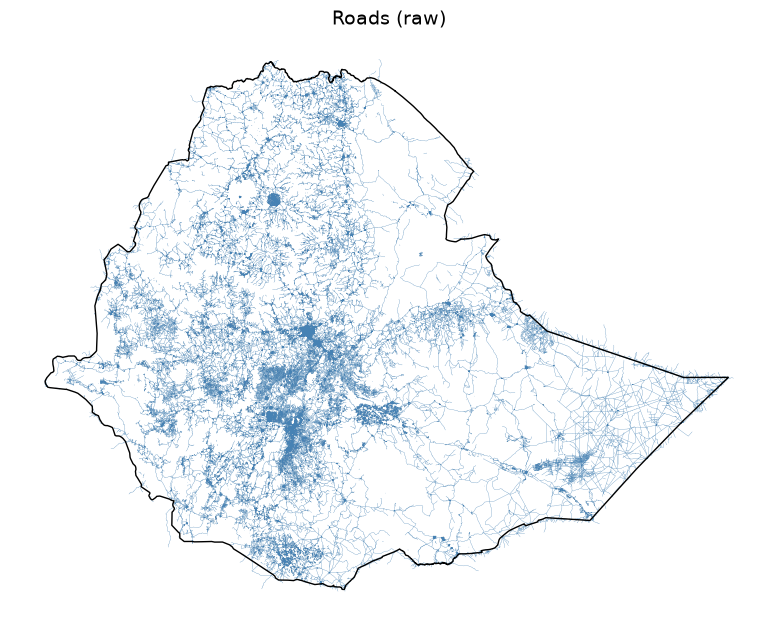

In [89]:
plot_vector_lines('ethiopia-latest-free/gis_osm_roads_free_1.shp', meta, color="steelblue", linewidth=0.2)

### Buildings (raw, centroid density)

In [90]:
meta = dict(
    title='Buildings (raw, centroid density)',
    category='Exposure -- infrastructure',
    source='OpenStreetMap building footprints, via Geofabrik Ethiopia extract',
    native_resolution='vector (no fixed grid resolution)',
    native_extent='Ethiopia (Geofabrik country extract)',
    native_format='ESRI Shapefile (polygons), 2,555,003 features',
    units='building count (shown as a fine-grid centroid density, not individual footprints -- plotting 2.5M filled polygons directly takes ~4.5 minutes and renders as a solid blob at country scale)',
    license='ODbL (OpenStreetMap contributors)',
    note="3 of 2.5M geometries are empty and dropped before centroid computation, matching the acquisition code's handling.",
)


In [91]:
def plot_building_density(meta, fname="ethiopia-latest-free/gis_osm_buildings_a_free_1.shp", grid_deg=0.05):
    meta = dict(meta)
    meta["path"] = fname
    print_metadata(meta)

    gdf = gpd.read_file(raw_dir / fname, columns=[])
    valid_geom = (~gdf.geometry.isna()) & (~gdf.geometry.is_empty)
    gdf = gdf[valid_geom]
    print(f"  Feature count: {len(gdf)}")
    centroids = gdf.geometry.centroid

    left, bottom, right, top = DOMAIN_BOUNDS
    nx = int(round((right - left) / grid_deg))
    ny = int(round((top - bottom) / grid_deg))
    density, xedges, yedges = np.histogram2d(
        centroids.x, centroids.y, bins=[nx, ny], range=[[left, right], [bottom, top]]
    )
    density = density.T  # rows = y, matching imshow's row-major top-down convention after flip
    density = np.flipud(density)
    density_masked = np.ma.masked_equal(density, 0)
    print(f"  Density grid: {nx} x {ny} cells (~{grid_deg} deg), max {int(density.max())} buildings/cell")

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(density_masked, cmap="viridis", extent=(left, right, bottom, top))
    cbar = fig.colorbar(im, ax=ax, pad=0.03, shrink=0.75, fraction=0.05)
    cbar.set_label(f"buildings per {grid_deg} deg cell", fontsize=10)
    plot_boundary_outline(ax)
    ax.set_title(meta["title"], fontsize=14)
    ax.axis("off")
    fig.tight_layout()
    display(fig)
    plt.close(fig)

Buildings (raw, centroid density)  (ethiopia-latest-free/gis_osm_buildings_a_free_1.shp)
  Category:          Exposure -- infrastructure
  Source:            OpenStreetMap building footprints, via Geofabrik Ethiopia extract
  Native resolution: vector (no fixed grid resolution)
  Native extent:     Ethiopia (Geofabrik country extract)
  Native format:     ESRI Shapefile (polygons), 2,555,003 features
  Units (native):    building count (shown as a fine-grid centroid density, not individual footprints -- plotting 2.5M filled polygons directly takes ~4.5 minutes and renders as a solid blob at country scale)
  License:           ODbL (OpenStreetMap contributors)
  Note:
    3 of 2.5M geometries are empty and dropped before centroid computation, matching the acquisition
    code's handling.
  Feature count: 2555000
  Density grid: 300 x 240 cells (~0.05 deg), max 37399 buildings/cell


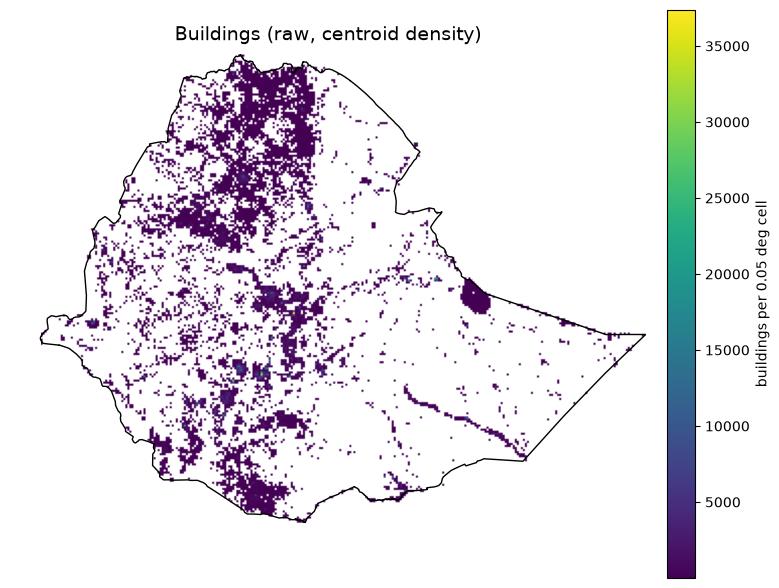

In [92]:
plot_building_density(meta, fname='ethiopia-latest-free/gis_osm_buildings_a_free_1.shp')

### Health Facilities (raw points)

In [93]:
meta = dict(
    title='Health facilities (raw points)',
    category='Exposure -- infrastructure / Vulnerability -- wet adaptive capacity',
    source='Global Healthsites Mapping Project, via HDX bulk CSV mirror',
    native_resolution='point-based (no fixed grid resolution)',
    native_extent='Ethiopia',
    native_format='CSV (columns X=longitude, Y=latitude, plus OSM health-facility tags)',
    units='facility locations (count computed downstream via point-in-cell binning)',
    license='ODbL (OpenStreetMap contributors, via Global Healthsites Mapping Project)',
    note='Rows with empty X/Y (way/relation geometries without a precomputed centroid) are dropped before plotting, matching the acquisition code.',
)

In [94]:
def plot_points_csv(fname, meta, lon_col, lat_col, value_col=None, cmap="viridis", point_size=4):
    meta = dict(meta)
    meta["path"] = fname
    print_metadata(meta)

    df = pd.read_csv(raw_dir / fname)
    df = df.dropna(subset=[lon_col, lat_col])
    print(f"  Point count (valid lon/lat): {len(df)}")
    if value_col:
        valid = df[value_col].dropna()
        print(f"  {value_col} stats: n={len(valid)}, min={valid.min():.3g}, mean={valid.mean():.3g}, max={valid.max():.3g}")

    fig, ax = plt.subplots(figsize=(8, 8))
    if value_col:
        sc = ax.scatter(df[lon_col], df[lat_col], c=df[value_col], cmap=cmap, s=point_size)
        cbar = fig.colorbar(sc, ax=ax, pad=0.03, shrink=0.75, fraction=0.05)
        cbar.set_label(meta["units"], fontsize=10)
    else:
        ax.scatter(df[lon_col], df[lat_col], color="firebrick", s=point_size, alpha=0.6)
    plot_boundary_outline(ax)
    ax.set_title(meta["title"], fontsize=14)
    ax.set_xlim(DOMAIN_BOUNDS[0], DOMAIN_BOUNDS[2])
    ax.set_ylim(DOMAIN_BOUNDS[1], DOMAIN_BOUNDS[3])
    ax.axis("off")
    fig.tight_layout()
    display(fig)
    plt.close(fig)

Health facilities (raw points)  (healthsites_eth.csv)
  Category:          Exposure -- infrastructure / Vulnerability -- wet adaptive capacity
  Source:            Global Healthsites Mapping Project, via HDX bulk CSV mirror
  Native resolution: point-based (no fixed grid resolution)
  Native extent:     Ethiopia
  Native format:     CSV (columns X=longitude, Y=latitude, plus OSM health-facility tags)
  Units (native):    facility locations (count computed downstream via point-in-cell binning)
  License:           ODbL (OpenStreetMap contributors, via Global Healthsites Mapping Project)
  Note:
    Rows with empty X/Y (way/relation geometries without a precomputed centroid) are dropped before
    plotting, matching the acquisition code.
  Point count (valid lon/lat): 777


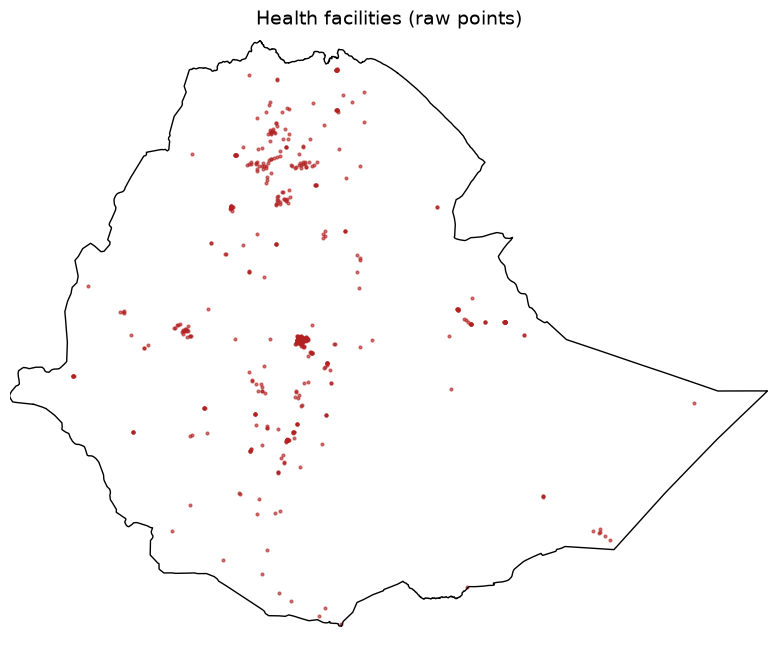

In [95]:
plot_points_csv('healthsites_eth.csv', meta, lon_col="X", lat_col="Y")

## Vulnerability Raw Sources

### Aridity Index (raw, scaled)

In [96]:
meta = dict(
    title='Aridity index (raw, scaled)',
    category='Vulnerability -- drought sensitivity',
    source='CGIAR-CSI Global Aridity Index v3.1',
    native_resolution='30 arcsec (~1 km)',
    native_extent='Global (18000 x 43200)',
    native_format='GeoTIFF, single band, uint16',
    units='raw scaled integer (documented convention: divide by 10000 for the true 0-1.5-ish aridity index; no embedded GDAL scale tag)',
    license='CC-BY 4.0',
    note='Plotted here BOTH as the raw uint16 values and, in the stats line, after applying the x0.0001 scale factor the acquisition code uses (verified against known semi-arid climate values).',
)


Aridity index (raw, scaled)  (cgiar_ai_et0_annual_v31/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif)
  Category:          Vulnerability -- drought sensitivity
  Source:            CGIAR-CSI Global Aridity Index v3.1
  Native resolution: 30 arcsec (~1 km)
  Native extent:     Global (18000 x 43200)
  Native format:     GeoTIFF, single band, uint16
  Units (native):    raw scaled integer (documented convention: divide by 10000 for the true 0-1.5-ish aridity index; no embedded GDAL scale tag)
  License:           CC-BY 4.0
  Note:
    Plotted here BOTH as the raw uint16 values and, in the stats line, after applying the x0.0001 scale
    factor the acquisition code uses (verified against known semi-arid climate values).
  Clipped stats (raw): n=1338021, min=447, mean=5.06e+03, max=1.63e+04
  Clipped stats (x0.0001 applied): min=0.0447, mean=0.506, max=1.63


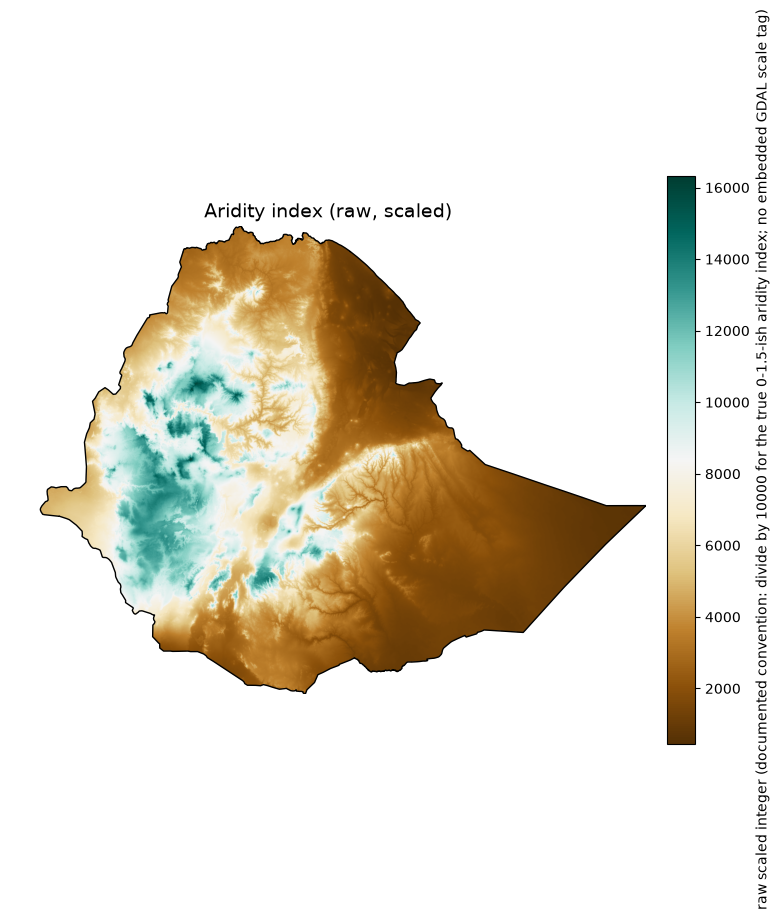

In [97]:
plot_raster_raw('cgiar_ai_et0_annual_v31/Global-AI_ET0__annual_v3_1/ai_v31_yr.tif', meta, cmap="BrBG", scale_factor=0.0001)

### Irrigated Area % (raw)

In [98]:
meta = dict(
    title='Irrigated area % (raw)',
    category='Vulnerability -- drought adaptive capacity',
    source='FAO/Bonn Global Map of Irrigation Areas v5',
    native_resolution='5 arcmin (~9 km, ~0.0833 deg)',
    native_extent='Global (2160 x 4320)',
    native_format='ESRI ASCII grid (no embedded CRS -- implicit WGS84)',
    units='% of cell area irrigated (0-100)',
    license='CC-BY 4.0',
    note='No CRS tag in the .asc file itself; assumed WGS84 (bounds run -180..180, -90..90, consistent with a global lat/lon grid).',
)

Irrigated area % (raw)  (gmia_v5_aei_pct_asc/gmia_v5_aei_pct.asc)
  Category:          Vulnerability -- drought adaptive capacity
  Source:            FAO/Bonn Global Map of Irrigation Areas v5
  Native resolution: 5 arcmin (~9 km, ~0.0833 deg)
  Native extent:     Global (2160 x 4320)
  Native format:     ESRI ASCII grid (no embedded CRS -- implicit WGS84)
  Units (native):    % of cell area irrigated (0-100)
  License:           CC-BY 4.0
  Note:
    No CRS tag in the .asc file itself; assumed WGS84 (bounds run -180..180, -90..90, consistent with a
    global lat/lon grid).
  Clipped stats: n=13398, min=0, mean=0.258, max=71


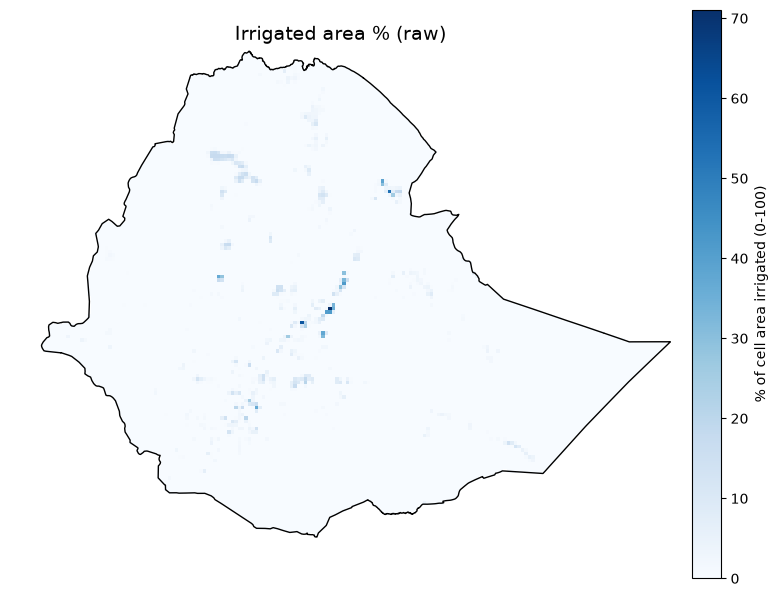

In [99]:
plot_raster_raw('gmia_v5_aei_pct_asc/gmia_v5_aei_pct.asc', meta, cmap="Blues")

### Electrification -- no access (raw, 2020 slice)

In [100]:
def plot_gdessa_raw(meta, fname="gdessa_noaccess_ssa_2014_2020.nc"):
    meta = dict(meta)
    meta["path"] = fname
    print_metadata(meta)

    ds = xr.open_dataset(raw_dir / fname)
    left, bottom, right, top = DOMAIN_BOUNDS
    da = ds["Pop_no_access_per_km2"].sel({"Time (Year)": 7})
    da = da.sel(Latitude=slice(top, bottom), Longitude=slice(left, right))
    data = da.values.astype(float)
    lats = da["Latitude"].values
    lons = da["Longitude"].values
    win_transform = rasterio.transform.from_bounds(
        lons.min(), lats.min(), lons.max(), lats.max(), data.shape[1], data.shape[0]
    )

    profile = dict(
        driver="GTiff", height=data.shape[0], width=data.shape[1], count=1,
        dtype="float64", crs="EPSG:4326", transform=win_transform, nodata=np.nan,
    )
    memfile = MemoryFile()
    with memfile.open(**profile) as dst:
        dst.write(np.nan_to_num(data, nan=np.nan), 1)
    src = memfile.open()
    try:
        clipped, out_transform = rasterio.mask.mask(src, [boundary_geom.__geo_interface__], crop=True)
        clipped_data = np.ma.masked_invalid(clipped[0])
        valid = clipped_data.compressed()
        if valid.size:
            print(f"  Clipped stats: n={valid.size}, min={valid.min():.3g}, mean={valid.mean():.3g}, max={valid.max():.3g}")
        else:
            print("  Clipped stats: no valid pixels within the boundary")

        fig, ax = plt.subplots(figsize=(8, 8))
        im = ax.imshow(clipped_data, cmap="magma", extent=rasterio.plot.plotting_extent(clipped_data, out_transform))
        cbar = fig.colorbar(im, ax=ax, pad=0.03, shrink=0.75, fraction=0.05)
        cbar.set_label(meta["units"], fontsize=10)
        plot_boundary_outline(ax)
        ax.set_title(meta["title"], fontsize=14)
        ax.axis("off")
        fig.tight_layout()
        display(fig)
        plt.close(fig)
    finally:
        src.close()
        memfile.close()
        ds.close()


In [101]:
meta = dict(
    title='Electrification -- no access (raw, 2020 slice)',
    category='Vulnerability -- drought + wet adaptive capacity',
    source='IIASA/Falchetta et al. GDESSA, variable Pop_no_access_per_km2',
    native_resolution='~1 km',
    native_extent='Sub-Saharan Africa (7395 x 8039 x 7 years, 1.9 GB total)',
    native_format='NetCDF (CF-1.4), dims (Time (Year) 1-7 = 2014-2020, Latitude, Longitude)',
    units='people without electricity access per km^2 (density)',
    license='CC-BY 4.0',
    note='Sub-Saharan-Africa-wide file; only the year-2020 slice (Time index 7) and the Ethiopia domain window are used downstream and shown here.',
)

Electrification -- no access (raw, 2020 slice)  (gdessa_noaccess_ssa_2014_2020.nc)
  Category:          Vulnerability -- drought + wet adaptive capacity
  Source:            IIASA/Falchetta et al. GDESSA, variable Pop_no_access_per_km2
  Native resolution: ~1 km
  Native extent:     Sub-Saharan Africa (7395 x 8039 x 7 years, 1.9 GB total)
  Native format:     NetCDF (CF-1.4), dims (Time (Year) 1-7 = 2014-2020, Latitude, Longitude)
  Units (native):    people without electricity access per km^2 (density)
  License:           CC-BY 4.0
  Note:
    Sub-Saharan-Africa-wide file; only the year-2020 slice (Time index 7) and the Ethiopia domain window
    are used downstream and shown here.
  Clipped stats: n=553491, min=1.01, mean=138, max=1.59e+04


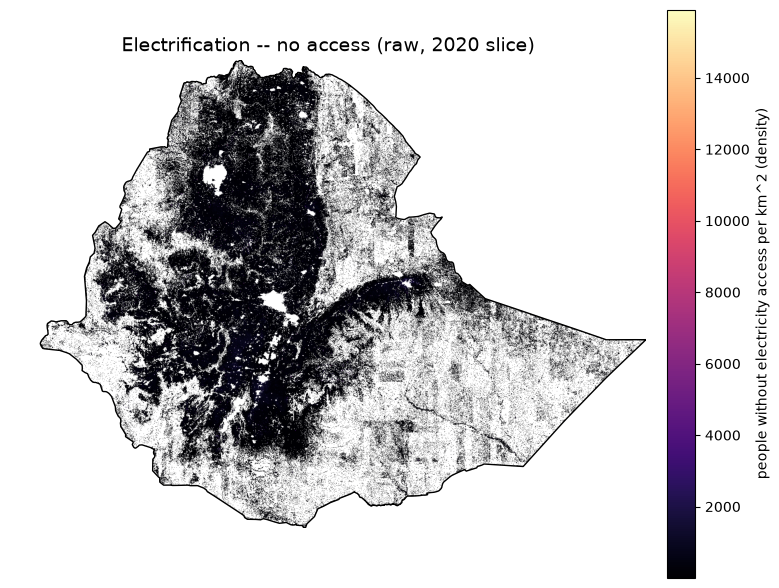

In [102]:
plot_gdessa_raw(meta, fname='gdessa_noaccess_ssa_2014_2020.nc')

### Rivers/ Waterways (raw)

In [103]:
meta = dict(
    title='Waterways (raw)',
    category='Vulnerability -- wet sensitivity (river/water-body distance input)',
    source='OpenStreetMap rivers/streams, via Geofabrik Ethiopia extract',
    native_resolution='vector (no fixed grid resolution)',
    native_extent='Ethiopia (Geofabrik country extract)',
    native_format='ESRI Shapefile (lines), 30,727 features',
    units='line geometries (distance-to-nearest computed downstream)',
    license='ODbL (OpenStreetMap contributors)',
)

Waterways (raw)  (ethiopia-latest-free/gis_osm_waterways_free_1.shp)
  Category:          Vulnerability -- wet sensitivity (river/water-body distance input)
  Source:            OpenStreetMap rivers/streams, via Geofabrik Ethiopia extract
  Native resolution: vector (no fixed grid resolution)
  Native extent:     Ethiopia (Geofabrik country extract)
  Native format:     ESRI Shapefile (lines), 30,727 features
  Units (native):    line geometries (distance-to-nearest computed downstream)
  License:           ODbL (OpenStreetMap contributors)
  Feature count: 30727


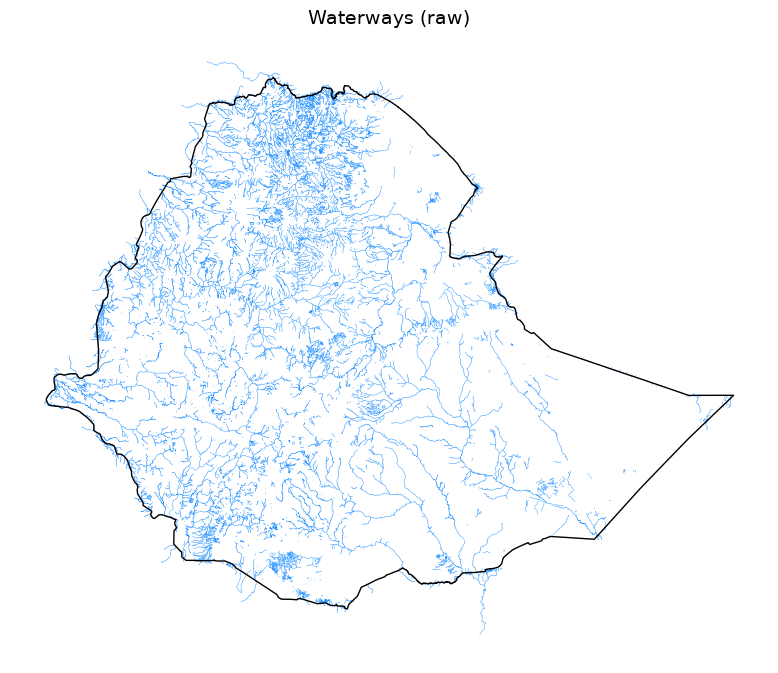

In [104]:
plot_vector_lines('ethiopia-latest-free/gis_osm_waterways_free_1.shp', meta, color="dodgerblue", linewidth=0.3)

### Water Bodies (raw)

In [105]:
def plot_vector_polygons(fname, meta, color="steelblue"):
    meta = dict(meta)
    meta["path"] = fname
    print_metadata(meta)

    gdf = gpd.read_file(raw_dir / fname, columns=[])
    print(f"  Feature count: {len(gdf)}")

    fig, ax = plt.subplots(figsize=(8, 8))
    gdf.plot(ax=ax, facecolor=color, edgecolor="none")
    plot_boundary_outline(ax)
    ax.set_title(meta["title"], fontsize=14)
    ax.axis("off")
    fig.tight_layout()
    display(fig)
    plt.close(fig)

In [106]:
meta = dict(
    title='Water bodies (raw)',
    category='Vulnerability -- wet sensitivity (river/water-body distance input)',
    source='OpenStreetMap lakes/reservoirs, via Geofabrik Ethiopia extract',
    native_resolution='vector (no fixed grid resolution)',
    native_extent='Ethiopia (Geofabrik country extract)',
    native_format='ESRI Shapefile (polygons), 12,907 features',
    units='polygon geometries (distance-to-nearest computed downstream)',
    license='ODbL (OpenStreetMap contributors)',
)


Water bodies (raw)  (ethiopia-latest-free/gis_osm_water_a_free_1.shp)
  Category:          Vulnerability -- wet sensitivity (river/water-body distance input)
  Source:            OpenStreetMap lakes/reservoirs, via Geofabrik Ethiopia extract
  Native resolution: vector (no fixed grid resolution)
  Native extent:     Ethiopia (Geofabrik country extract)
  Native format:     ESRI Shapefile (polygons), 12,907 features
  Units (native):    polygon geometries (distance-to-nearest computed downstream)
  License:           ODbL (OpenStreetMap contributors)
  Feature count: 12907


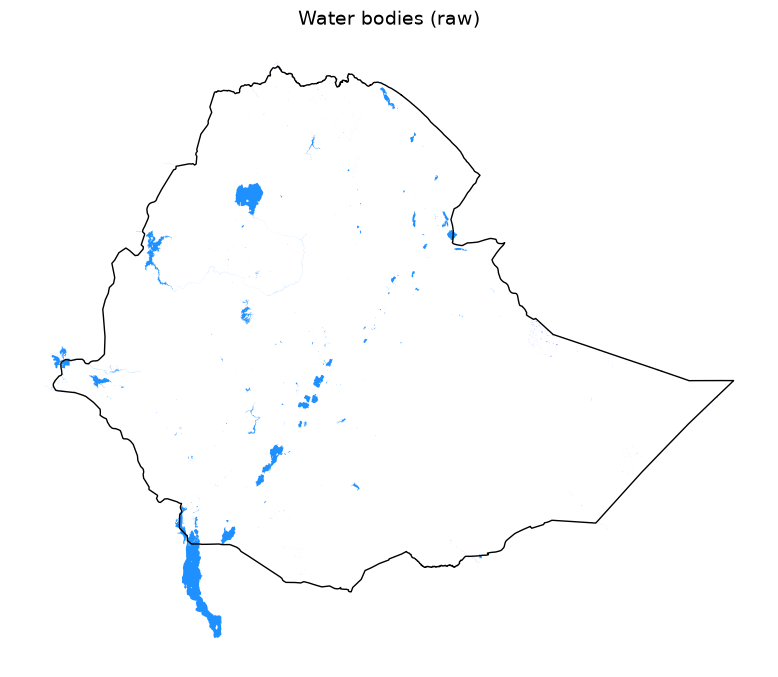

In [107]:
plot_vector_polygons('ethiopia-latest-free/gis_osm_water_a_free_1.shp', meta, color="dodgerblue")

### Relative Wealth Index (raw points)

In [108]:
meta = dict(
    title='Relative Wealth Index (raw points)',
    category='Vulnerability -- drought + wet sensitivity',
    source='Meta Relative Wealth Index (Data for Good, via HDX)',
    native_resolution='~2.4 km (point resolution)',
    native_extent='Ethiopia',
    native_format='CSV (columns latitude, longitude, rwi, error)',
    units='index (unitless, roughly -1 to +1, centered near 0; higher = wealthier)',
    license='CC-BY 4.0 (Meta Data for Good)',
)

Relative Wealth Index (raw points)  (meta_rwi_eth.csv)
  Category:          Vulnerability -- drought + wet sensitivity
  Source:            Meta Relative Wealth Index (Data for Good, via HDX)
  Native resolution: ~2.4 km (point resolution)
  Native extent:     Ethiopia
  Native format:     CSV (columns latitude, longitude, rwi, error)
  Units (native):    index (unitless, roughly -1 to +1, centered near 0; higher = wealthier)
  License:           CC-BY 4.0 (Meta Data for Good)
  Point count (valid lon/lat): 85142
  rwi stats: n=85142, min=-1.49, mean=-0.358, max=1.98


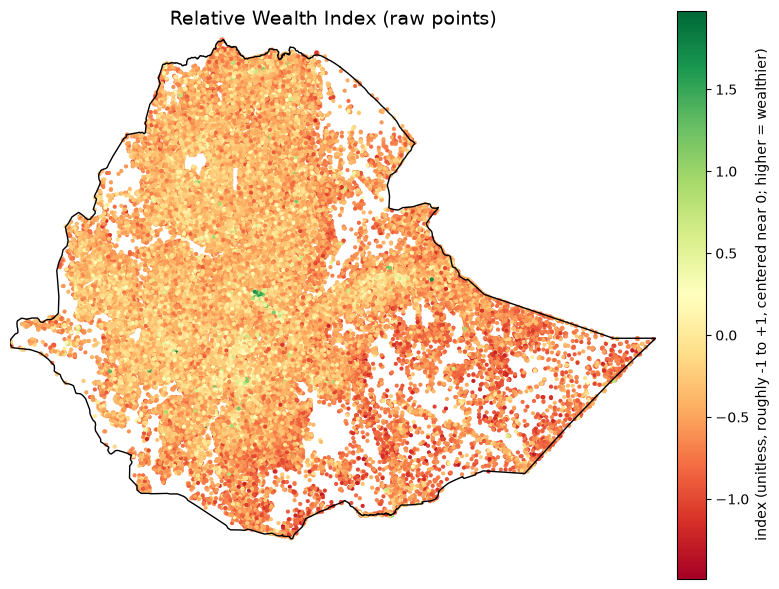

In [109]:
plot_points_csv('meta_rwi_eth.csv', meta, lon_col="longitude", lat_col="latitude", value_col="rwi", cmap="RdYlGn")